# **Life Hash: Cryptographic Hashing via Discrete Dynamical Systems**

This project explores the application of Discrete Dynamical Systems (DDS), specifically two-dimensional Cellular Automata (CA), in the design of experimental cryptographic hash functions. Unlike traditional bitwise-manipulation algorithms, the 'Life Hash' treats input data as a stochastic seed for a spatial grid simulation.

### Mathematical Foundations
*   **Non-Linear State Transitions**: We utilize the emergent complexity of Conway-style transition rules. These rules are non-linear and local, ensuring that small perturbations in the initial bitstream (the 'seed') propagate chaotically across the grid.
*   **One-Way Function Properties**: Cellular automata are naturally suited for one-way functions. While computing the next state is computationally trivial, inverting the system to find the pre-image from a future state is an NP-hard problem for many CA configurations.
*   **Non-Invertible Transformations**: Through iterative 'evolution' steps, the algorithm ensures that every bit of the output is a complex, non-invertible function of the entire input string, satisfying the diffusion requirements of a secure hash.

### Objective
To demonstrate that spatial 'diffusion' through cyclic shifting, followed by iterative 'evolution' in a 2D CA environment, effectively destroys linguistic markers and patterns inherent in human-generated data (e.g., passwords).

# Data Acquisition and Baseline Analysis

## Linguistic Feature Schema
To benchmark the efficiency of the Life Hash algorithm, we first analyze the statistical properties of human-generated data. This involves importing a corpus of common passwords and extracting a multi-dimensional feature set.

### Methodology
*   **Schema Definition**: The dataset is loaded using `pandas`, targeting eight specific linguistic features (e.g., character counts, vowel/consonant ratios, and complexity metrics). This provides a structured representation of high-predictability human input.
*   **Entropy Baseline**: By calculating the mean values of these numeric features, we establish a 'control' state. This baseline allows us to quantify the degree of diffusion and pattern destruction achieved by the subsequent discrete dynamical transformations. This initial state represents the 'signal' before we introduce algorithmic 'noise'.

In [18]:
import pandas as pd

pd.set_option("display.max_columns", 25)

Passwords = pd.read_csv("passwords.csv")
display(Passwords.head(23).T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
password,123456,password,12345678,qwerty,123456789,12345,1234,111111,1234567,dragon,123123,wrongpassword,abc123,football,monkey,letmein,696969,shadow,master,666666,qwertyuiop,123321,mustang
length,6,8,8,6,9,5,4,6,7,6,6,13,6,8,6,7,6,6,6,6,10,6,7
num_chars,0,8,0,6,0,0,0,0,0,6,0,13,3,8,6,7,0,6,6,0,10,0,7
num_digits,6,0,8,0,9,5,4,6,7,0,6,0,3,0,0,0,6,0,0,6,0,6,0
num_upper,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
num_lower,0,8,0,6,0,0,0,0,0,6,0,13,3,8,6,7,0,6,6,0,10,0,7
num_special,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
num_vowels,0,2,0,1,0,0,0,0,0,2,0,3,1,3,2,3,0,2,2,0,4,0,2
num_syllables,1,2,1,3,1,1,1,1,1,2,1,3,1,2,2,2,1,2,2,1,3,1,2


### Statistical Baseline and Diffusion Control

Before applying discrete dynamical transformations, we establish a quantitative 'fingerprint' of the input data. This aggregate analysis serves as the mathematical control for our experiment.

- **Feature Distribution**: By visualizing the mean of every numeric feature, we identify the linguistic signals (e.g., high lowercase and vowel density) that characterize human-generated passwords.

- **Measuring Diffusion**: This visualization provides the baseline entropy state. Success in the Life Hash algorithm is defined by the degree to which the final hash distribution diverges from this profile, indicating successful pattern destruction and high diffusion.

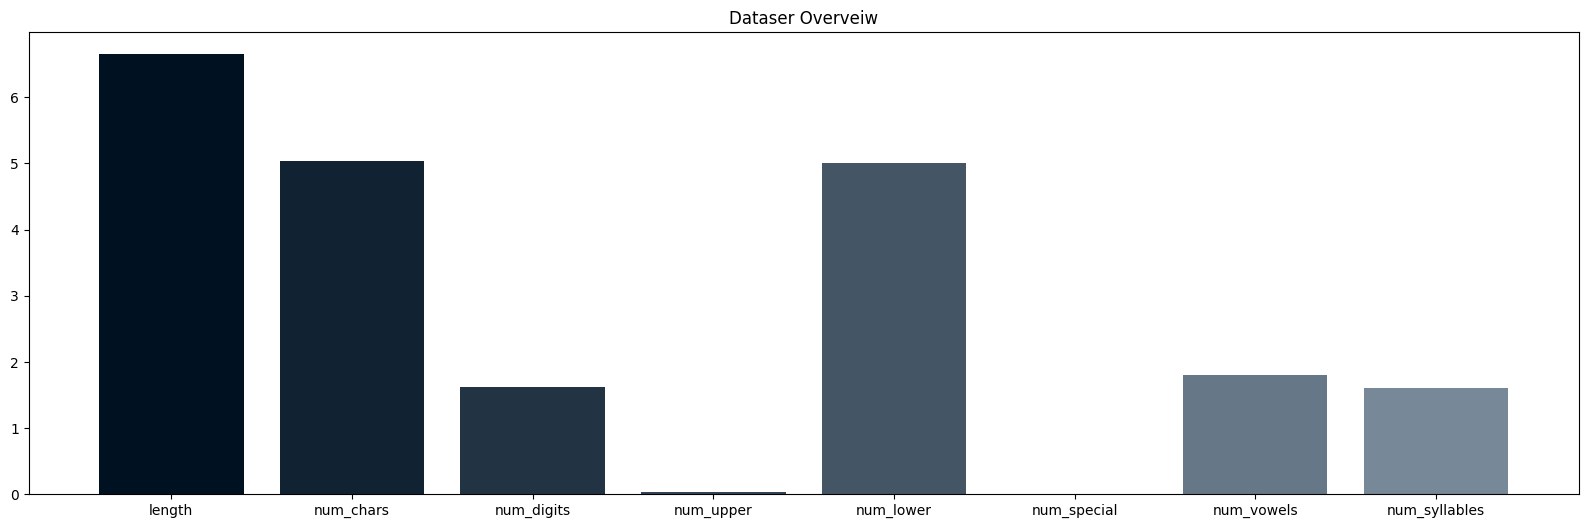

In [19]:
from matplotlib import pyplot as plt

plt.figure(figsize = (20, 6))
plt.bar(x = Passwords.columns[1:], height = Passwords.drop(columns = "password").mean(), color = ["#" + "".join([f"{i + j}" * 2 for j in range(3)]) for i in range(len(Passwords.columns))])
plt.title("Dataser Overveiw")
plt.show()

### The Transformation Pipeline: Bitstream Mapping & Spatial Diffusion

This section defines the core architecture for converting raw linguistic data into a format suitable for discrete dynamical simulation. We utilize a series of geometric and bitwise operations to ensure high-entropy initialization.

1. The mapping process begins with the `encode` and `setup` functions, which transform variable-length strings into a fixed-dimension binary grid (7 x 23).
    - **encode**: Converts the input string into a flat 8-bit binary array based on ASCII values.
    - **setup**: Prepares the 2D game board. If the input exceeds 161 bits, it performs an XOR fold to ensure every bit influences the hash. For shorter inputs, it utilizes **Cyclic Completion** (repeating the start of the bitstream) to fully saturate the grid without zero-padding.

2. Spatial diffusion is achieved via the `shuffle` function, which relocates bit clusters to maximize the future avalanche effect.
    - **shuffle**: Implements a position-dependent shift using `np.roll`. It calculates row and column offsets based on index parity (i % 2), effectively destroying the linguistic continuity of the original password.

3. Finally, the `decode` function provides the inverse mapping to generate the printable signature.
    - **decode**: Flattens the evolved grid and maps the binary chunks back to the printable ASCII range (32-126), resulting in the final human-readable hash string.

In [20]:
import numpy as np

pd.set_option("display.max_colwidth", 130)

def encode(text : str) :
  binary = np.array([int(i) for i in ''.join([format(ord(char), '08b') for char in text])])
  return binary

def setup(binary : np.array, ratio : list[int, int] = [7, 19]) :
  size = ratio[0] * ratio[1]

  if len(binary) == 0 :
    output = np.zeros(size, dtype = int)
  elif len(binary) > size :
    output = binary[:size].copy()
    remaining = binary[size:]
    for i in range(0, len(remaining), size):
        chunk = remaining[i : i + size]
        if len(chunk) < size : chunk = np.pad(chunk, (0, size - len(chunk)), 'constant')
        output = output ^ chunk
  else:
    output = np.concatenate([binary] * (size // len(binary)) + [binary[: size % len(binary)]])

  board = output.reshape((ratio[0], ratio[1]))
  return board

Data = pd.DataFrame({"Passwords" : Passwords["password"]})
Data["Raw"] = [setup(encode(i)) for i in Data["Passwords"]]

def shuffle(binary : np.array) :
  rows, cols = [np.array([i % 2 for i in range(axe)]) for axe in binary.shape]
  binary = np.roll(binary, rows, axis = 0)
  binary = np.roll(binary, cols, axis = 1)
  return binary

def decode(board: np.array, limits : tuple[int, int] | None = (32, 126)) :
  binary = ''.join(str(bit) for bit in board.flatten())
  if len(binary) % 8 != 0: binary += binary[:(8 - len(binary) % 8)]
  chunks = [binary[i : i + 8] for i in range(0, len(binary), 8)]

  text = ''.join([chr(limits[0] + (((int(chunk, 2) - limits[0]) % (limits[1] - limits[0] + 1)))) for chunk in chunks])
  return text

Data["Start"] = [shuffle(i) for i in Data["Raw"]]
Data["Shuffled"] = [decode(i) for i in Data["Start"]]

display(Data.head(10))

,Passwords,Raw,Start,Shuffled
0,123456,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, ...","[[0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 1, ...","MBM""*l:&LHlmbMGl+"
1,password,"[[0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1], [1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1], [1, 1, ...","[[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0], [1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0], [0, 1, ...","},<|Z|4B}u.}&|""z}"
2,12345678,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, ...","[[1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0], [0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0], [1, 0, ...","np.""KlZ&LHlmnMCnm"
3,qwerty,"[[0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1], [0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1], [0, 0, ...","[[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1], [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0], [0, 0, ...",}r^|)>+0}T+\$}J?y
4,123456789,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, ...","[[1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0], [0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0], [0, 1, ...",-*.IBpR&LHlmnMSnk
5,12345,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, ...","[[0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0], [0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0], [0, 0, ...",LJ.`9MJ&LHlmdLhlk
6,1234,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1, ...","[[1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0], [0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 1, ...","np-""*l:&LHdmfLCmm"
7,111111,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1], [1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0], [0, 1, ...","[[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0], [0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0], [0, 0, ...",Lh-I)M*$LBdLbLblJ
8,1234567,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1], [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1], [0, 1, ...","[[0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1], [0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0], [0, 0, ...",lxNjQ.*&LHlmnMElH
9,dragon,"[[0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1], [0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1], [1, 1, ...","[[1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1], [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0], [0, 1, ...",|\|4!|jdz}yXi|#}?


### Visualizing Grid Transformations: Entropy & Conservation

This diagnostic suite provides a multi-view verification of our spatial diffusion logic. Before the system evolves through the dynamical simulation, we must ensure the integrity of the initial data mapping.

-   The visualization process uses a four-pane diagnostic suite to compare the state of the grid before and after the deterministic shuffle.

-   The diagnostic elements are generated with:
    -   **Raw Board**: Visualizing the direct mapping of ASCII characters to a 2D binary grid.
    -   **Shuffled Board**: Rendering the grid after the position-dependent roll has relocated bit clusters.
    -   **Differences**: A heatmap highlighting the Hamming distance between the raw and shuffled states, confirming the dispersal of bits across the plane.

-   Finally, a `Cell counts` bar chart is displayed to verify that the shuffle is a lossless permutation. This ensures that the total number of active bits remains identical, preserving the initial information density before the simulation phase.

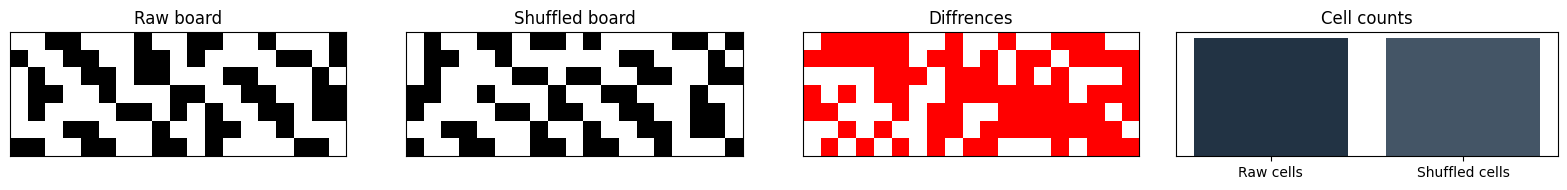

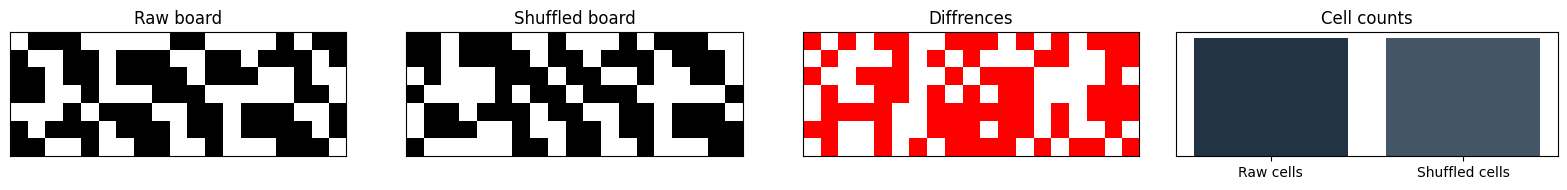

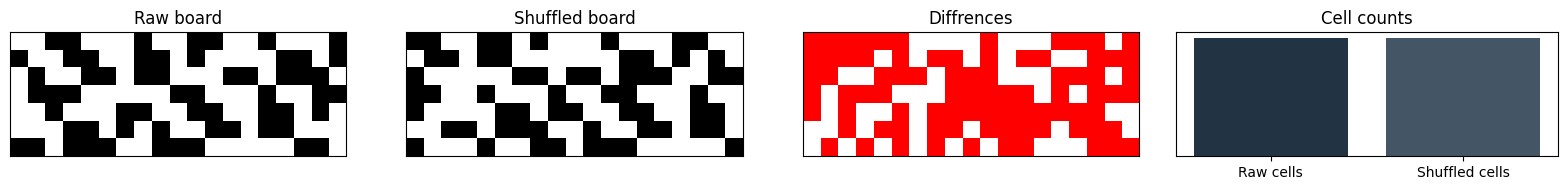

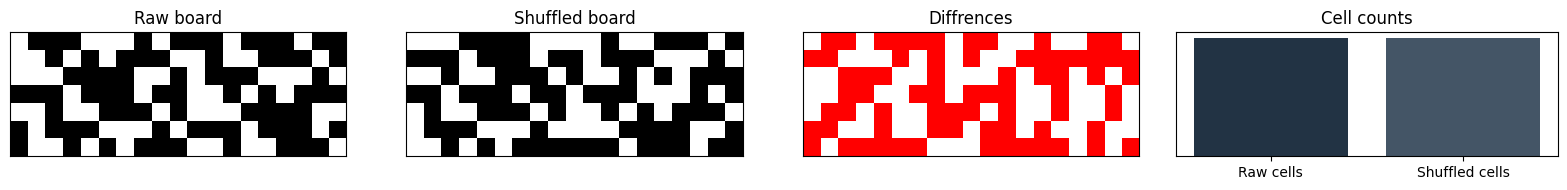

In [21]:
from matplotlib.colors import LinearSegmentedColormap

Examples = Data.loc[: 3, ["Raw", "Start"]]

for i in range(len(Examples)) :
  fig, axes = plt.subplots(1, 4, figsize = (16, 2))

  axes[0].imshow(Examples.loc[i, "Raw"], cmap = 'binary')
  axes[0].set_title('Raw board')
  axes[0].set_xticks([])
  axes[0].set_yticks([])

  axes[1].imshow(Examples.loc[i, "Start"], cmap = 'binary')
  axes[1].set_title('Shuffled board')
  axes[1].set_xticks([])
  axes[1].set_yticks([])

  axes[2].imshow(Examples.loc[i, "Raw"] != Examples.loc[i, "Start"] , cmap = LinearSegmentedColormap.from_list('RedWhite', ['white', 'red'], N = 2))
  axes[2].set_title('Diffrences')
  axes[2].set_xticks([])
  axes[2].set_yticks([])

  axes[3].bar(x = ["Raw cells", "Shuffled cells"], height = [np.sum(Examples.loc[i, "Raw"] == 1), np.sum(Examples.loc[i, "Start"] == 1)], color = ["#223344", "#445566"])
  axes[3].set_title('Cell counts')
  axes[3].set_yticks([])

  plt.tight_layout()
  plt.show()

### Simulation Mechanics: The Cellular Mixer

This section outlines the core one-way engine of the Life Hash, utilizing discrete logical updates to create chaotic diffusion through spatial interaction.

- The `update` function is the primary engine for state transitions. It determines the next generation of the hash grid by analyzing local bit-densities using a convolutional approach.

- The simulation is governed by a `Mega-Update` logic using `scipy.signal.convolve2d` with:
    - `kernel`: A 3 x 3 identity matrix that sums the eight neighbors of every cell simultaneously.
    - `boundary = 'wrap'`: Ensuring that information at the grid edges wraps around, creating a continuous toroidal surface for data diffusion.

- Transition rules are applied to the neighborhood sums to enforce non-linear evolution:
    - **survive**: Bits remain active if they have between 2 and 5 neighbors, preventing premature stasis of the hash.
    - **reproduce**: New bits are generated in empty cells with 1 or 3 neighbors, ensuring high information density across the grid.

- Finally, the `iterate` function recursively applies these rules. This forces the input data through multiple temporal layers, ensuring that the final output is a non-invertible function of the original seed.

In [22]:
import scipy.signal

pd.set_option("display.max_colwidth", 45)

def update(board : np.ndarray) :
  kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])
  neighbours = scipy.signal.convolve2d(board, kernel, mode = 'same', boundary = 'wrap')

  output = np.zeros_like(board, dtype = np.int8)
  suvive = (board == 1) & ((neighbours == 2) | (neighbours == 3) | (neighbours == 4) | (neighbours == 5))
  reproduce = (board == 0) & ((neighbours == 3) | (neighbours == 1))

  output[suvive | reproduce] = 1
  return output

def iterate(Start : pd.Series, iterations = 1):
    if iterations <= 0 : return "Start"

    previous = "Start"
    for i in range(1, iterations + 1):
        Data[f"{i}"] = [update(board) for board in Data[previous]]
        previous = f"{i}"
    return previous

Data = Data[["Passwords", "Raw", "Start", "Shuffled"]].copy()
last = iterate(Data["Start"], iterations = 2)

Data["End"] = [update(i) for i in Data[last]]
Data["Hash"] = [decode(i) for i in Data["End"]]

display(Data.head(10))

,Passwords,Raw,Start,Shuffled,1,2,End,Hash
0,123456,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, ...","MBM""*l:&LHlmbMGl+","[[0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ...","[[0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, ...","[[0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, ...","ENP(J_<*MK0N,I:oi"
1,password,"[[0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...","[[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, ...","},<|Z|4B}u.}&|""z}","[[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, ...","[[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, ...","[[1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, ...","},;[*7<R}u.}6{`z}"
2,12345678,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, ...","np.""KlZ&LHlmnMCnm","[[1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, ...","[[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, ...","[[1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, ...",.) %j_V6OJnVOUK}k
3,qwerty,"[[0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, ...","[[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, ...",}r^|)>+0}T+\$}J?y,"[[0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...","[[0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...","[[0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, ...",yr^\)F/.~s1\$yZ?w
4,123456789,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, ...",-*.IBpR&LHlmnMSnk,"[[1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, ...","[[0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, ...","[[0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, ...",.LNE%/\&LKn.nG[n*
5,12345,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, ...",LJ.`9MJ&LHlmdLhlk,"[[0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ...","[[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, ...","[[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, ...","HK|E6 F""L, >DEh1y"
6,1234,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, ...","np-""*l:&LHdmfLCmm","[[1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, ...","[[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, ...","[[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, ...",Nfl(J_@*LK0+7NK}t
7,111111,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, ...",Lh-I)M*$LBdLbLblJ,"[[0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, ...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[[0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, ...","t.`h>~$""Lk@4jB__b"
8,1234567,"[[0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, ...","[[0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, ...",lxNjQ.*&LHlmnMElH,"[[0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, ...","[[0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, ...","[[0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, ...",-U^KUN*&Lln/.M]}I
9,dragon,"[[0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, ...","[[1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ...",|\|4!|jdz}yXi|#}?,"[[1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, ...","[[1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, ...","[[1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, ...",|Lr6#|\Tdy|Yi|#s7


## Visual Evidence of Transformation: The Bitwise Journey
This section provides a qualitative assessment of how data moves through the pipeline, from raw input to the final digital signature.

### Purpose
*   To visually verify the destruction of the original data's spatial identity.
*   To monitor 'System Energy' (live cell counts) across the various stages of transformation.

### Visualization Breakdown
*   **Raw**: The deterministic grid immediately following ASCII encoding and XOR folding.
*   **Start**: The grid after the position-dependent shuffle has been applied.
*   **End**: The final state after the Game of Life simulation has completed.
*   **Bit Distribution**: A bar chart comparing the total count of '1' bits at each stage. This reveals that while the shuffle is conservative (lossless), the simulation is non-conservative, intentionally adding or destroying information to create a one-way signature.

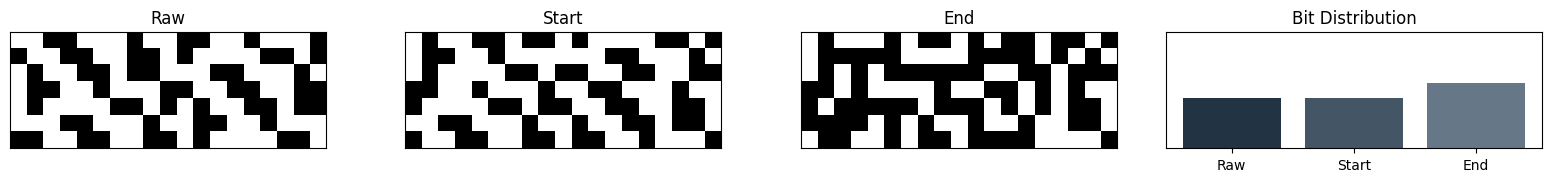

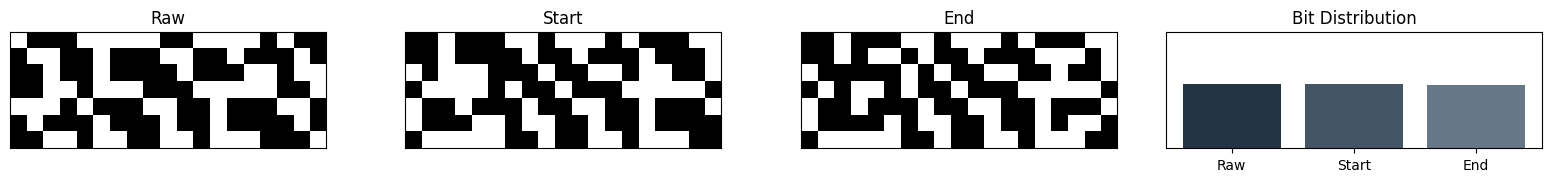

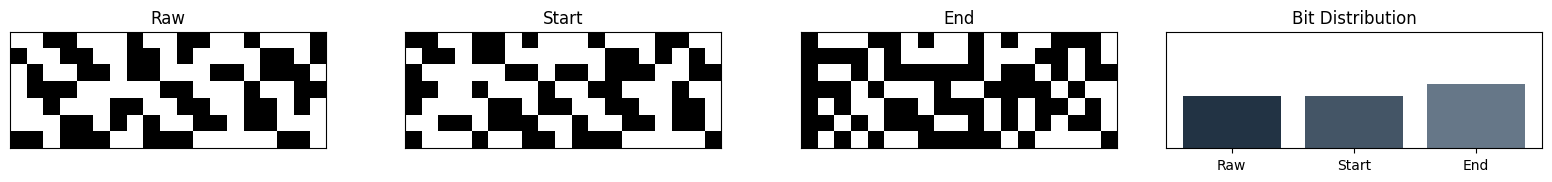

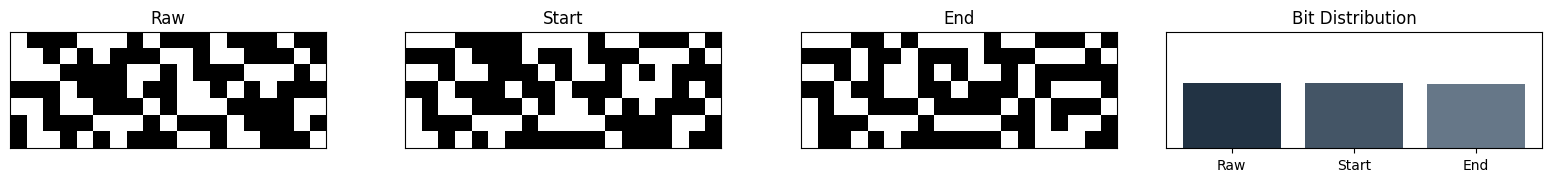

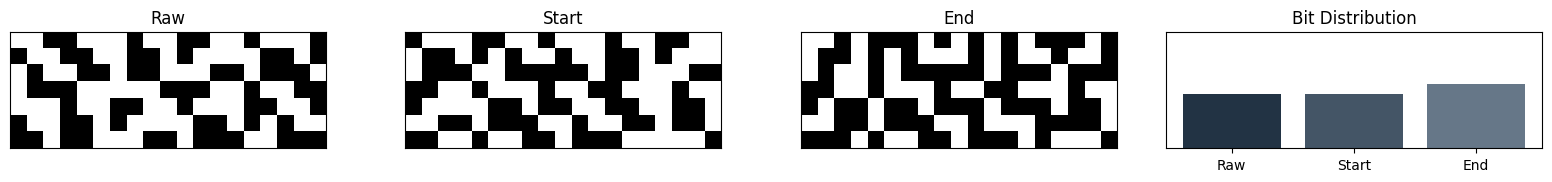

In [23]:
Examples = Data.head(5)

for i in range(len(Examples)) :
  fig, axes = plt.subplots(1, 4, figsize = (16, 2))

  axes[0].imshow(Examples.loc[i, "Raw"], cmap = 'binary')
  axes[0].set_title("Raw")
  axes[0].set_xticks([])
  axes[0].set_yticks([])

  axes[1].imshow(Examples.loc[i, "Start"], cmap = 'binary')
  axes[1].set_title("Start")
  axes[1].set_xticks([])
  axes[1].set_yticks([])

  axes[2].imshow(Examples.loc[i, "End"], cmap = 'binary')
  axes[2].set_title("End")
  axes[2].set_xticks([])
  axes[2].set_yticks([])

  stages = ['Raw', 'Start', 'End']
  counts = [np.sum(Examples.loc[i, 'Raw'] == 1), np.sum(Examples.loc[i, 'Start'] == 1), np.sum(Examples.loc[i, 'End'] == 1)]

  axes[3].bar(['Raw', 'Start', 'End'], counts, color = ["#223344", "#445566", "#667788"])
  axes[3].set_title('Bit Distribution')
  axes[3].set_yticks([])
  axes[3].set_ylim(0, Data.loc[i, 'Raw'].size)

  plt.tight_layout(pad = 1.35)
  plt.show()

### Feature Extraction for Generated Hashes: The Entropy Audit

To mathematically validate the efficacy of our 'Life Hash' algorithm, we subject the generated output to a statistical inspection. We treat the hashes as if they were passwords to determine the shift in character distribution.

*   **Schema Matching**: We extract 6 key features from the `Hashs` DataFrame: `length`, `num_digits`, `num_upper`, `num_lower`, `num_chars`, and `num_special`.
*   **Pattern Neutralization**: The core objective is to verify the 'Flattening' of the data. We specifically monitor how the Game of Life transformation balances the counts of digits and special characters compared to the original human-generated passwords.

In [24]:
pd.set_option("display.max_colwidth", 10)
pd.set_option("display.max_columns", 22)

Hashs = pd.DataFrame({"Hash": Data["Hash"]})

Hashs["length"] = Hashs["Hash"].apply(len)
Hashs["num_digits"] = Hashs["Hash"].apply(lambda x: sum(c.isdigit() for c in x))
Hashs["num_upper"] = Hashs["Hash"].apply(lambda x: sum(c.isupper() for c in x))
Hashs["num_lower"] = Hashs["Hash"].apply(lambda x: sum(c.islower() for c in x))
Hashs["num_chars"] = Hashs["Hash"].apply(lambda x: sum(c.isalpha() for c in x))
Hashs["num_special"] = Hashs["Hash"].apply(lambda x: sum(not c.isalnum() for c in x))

display(Hashs.head(22).T)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
Hash,ENP(J_...,"},;[*7...",.) %j_...,yr^\)F...,.LNE%/...,HK|E6 ...,Nfl(J_...,t.`h>~...,-U^KUN...,|Lr6#|...,LL}/IM...,"C,PW+l...",e.;~i|...,~kjQSY...,"^Q:Z,z...",Y#z<I]...,/IOIS=...,~DZ|9\...,\P:S)y...,".RN""R0...",]l=:k=...,B[}xI?...
length,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
num_digits,1,2,1,1,0,2,2,1,0,2,2,1,1,1,0,0,0,1,0,1,2,1
num_upper,8,1,7,2,6,7,6,2,7,3,9,3,2,5,9,6,7,4,6,6,2,4
num_lower,2,2,3,5,3,2,3,5,2,5,2,4,8,4,3,6,4,5,1,3,4,3
num_chars,10,3,10,7,9,9,9,7,9,8,11,7,10,9,12,12,11,9,7,9,6,7
num_special,6,12,6,9,8,6,6,9,8,7,4,9,6,7,5,5,6,7,10,7,9,9


# Statistical Validation and Conclusion

## Linguistic Audit and Pattern Destruction

This final section presents the quantitative proof of the transformation by comparing the original 'Dataset Overview' with the 'Hashs Overview'.

*   **Uniformity and Diffusion**: A strong hash should move toward a more balanced profile. By analyzing the mean values of `num_digits`, `num_special`, and character casing, we can see how the Cellular Automaton has successfully 'anonymized' the input data.
*   **Avalanche Effect Success**: The shift in these mean values confirms that the spatial transformations and discrete logical updates have achieved high diffusion.
*   **Final Assessment**: Through these iterative spatial evolutions, we have effectively converted low-entropy human inputs into a high-entropy digital signature, demonstrating the viability of cellular automata as an engine for experimental information security.

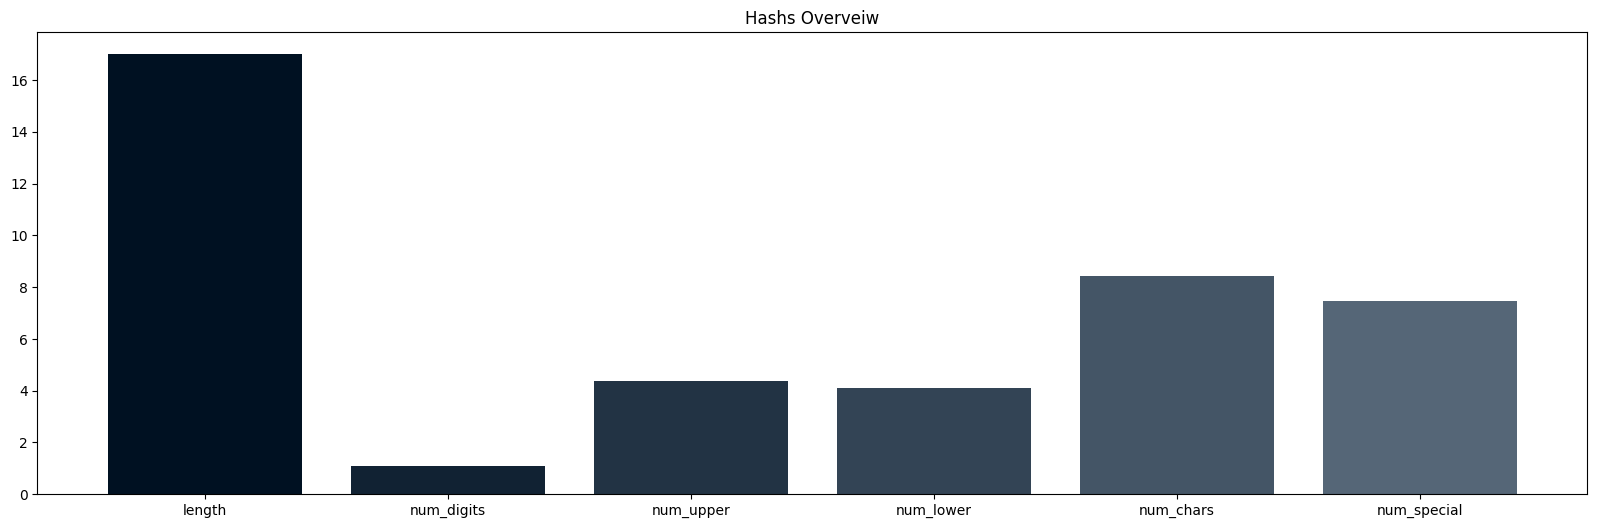

In [25]:
plt.figure(figsize = (20, 6))
plt.bar(x = Hashs.columns[1:], height = Hashs.drop(columns = "Hash").mean(), color = ["#" + "".join([f"{i + j}" * 2 for j in range(3)]) for i in range(len(Passwords.columns))])
plt.title("Hashs Overveiw")
plt.show()